In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df=sns.load_dataset("diamonds")

In [4]:
df.shape

(53940, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [6]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
df["cut"].unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']

In [8]:
df["color"].unique()

['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']

In [9]:
df["clarity"].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [10]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [11]:
df.rename(columns={
    'x': 'length',
    'y': 'width',
    'z': 'dpt'
}, inplace=True)

In [12]:
df.head()

,carat,cut,color,clarity,depth,table,price,length,width,dpt
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<Axes: xlabel='price'>

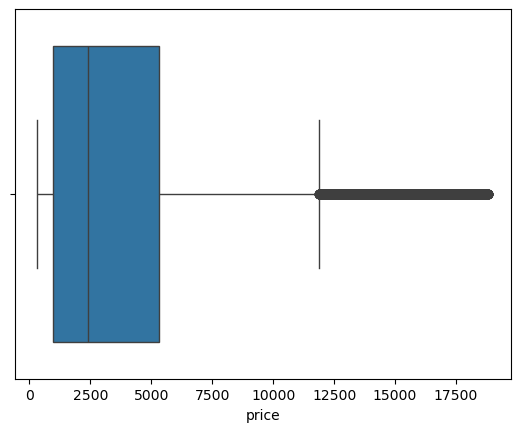

In [13]:
sns.boxplot(data=df,x="price")

In [14]:
df.head()

,carat,cut,color,clarity,depth,table,price,length,width,dpt
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [15]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
length     0
width      0
dpt        0
dtype: int64

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.head()

,carat,cut,color,clarity,depth,table,price,length,width,dpt
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


<Axes: xlabel='carat', ylabel='price'>

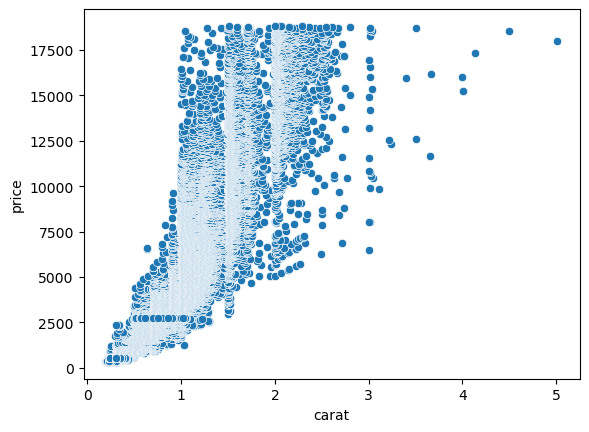

In [19]:
sns.scatterplot(data=df,x="carat",y="price")

<Axes: xlabel='cut', ylabel='price'>

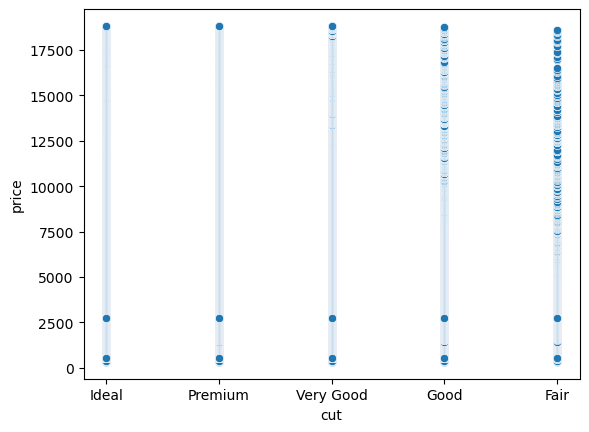

In [20]:
sns.scatterplot(data=df,x="cut",y="price")

<Axes: xlabel='clarity', ylabel='price'>

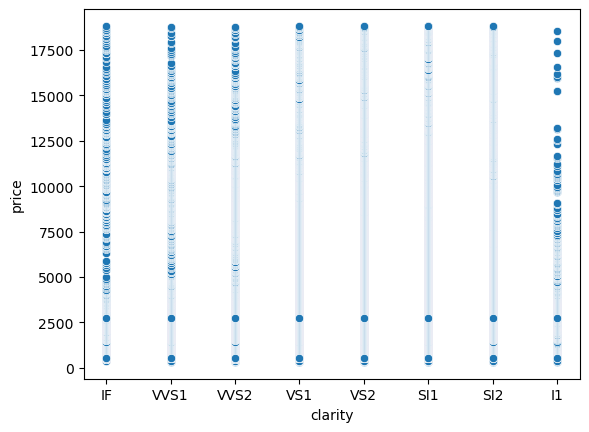

In [21]:
sns.scatterplot(data=df,x="clarity",y="price")

<Axes: xlabel='color', ylabel='price'>

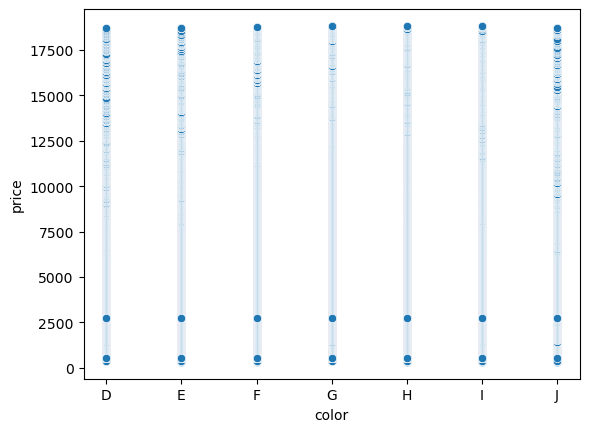

In [22]:
sns.scatterplot(data=df,x="color",y="price")

<Axes: xlabel='table', ylabel='price'>

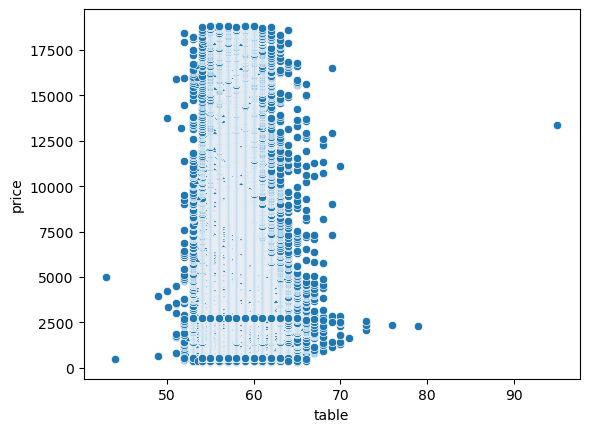

In [23]:
sns.scatterplot(data=df,x="table",y="price")

In [24]:
df.head()

,carat,cut,color,clarity,depth,table,price,length,width,dpt
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53794 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53794 non-null  float64 
 1   cut      53794 non-null  category
 2   color    53794 non-null  category
 3   clarity  53794 non-null  category
 4   depth    53794 non-null  float64 
 5   table    53794 non-null  float64 
 6   price    53794 non-null  int64   
 7   length   53794 non-null  float64 
 8   width    53794 non-null  float64 
 9   dpt      53794 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.4 MB


In [26]:
cata=["cut","color","clarity"]
num=["carat","depth","table","length","width","dpt"]

In [28]:
# using StandardScaler to scale the data and OneHotEncoder to change the catagorical in numeric 
perp=ColumnTransformer(transformers=[("num",StandardScaler(),num),
                                           ("cat",OneHotEncoder(drop="first",sparse_output=False),cata)])

In [29]:
x=df.drop("price",axis=1)
y=df["price"]
# now asigning the values the x and y

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
# now spliting the data into train and test 
# model will be test on 20% of the data
# model will be train on 80% of the data

In [31]:
x_train_s=perp.fit_transform(x_train)
x_test_s=perp.transform(x_test)
# now transform and fit the model from the data after geting the data from StandardScaler and OneHotEndor

In [32]:
df.head()

,carat,cut,color,clarity,depth,table,price,length,width,dpt
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [35]:
model=LinearRegression()
# now i call the linear Regression 

In [36]:
model.fit(x_train_s,y_train)
# now i train the model on the data
# after that the model will be train

LinearRegression()

In [38]:
p=model.predict(x_test_s)
p
# now we will use variable P to make predictions using the model

array([  700.07217051,  3754.66272195,  2630.13669808, ...,
        1396.6899335 , 11298.58750591,  1483.7827687 ])

In [41]:
r2_score(y_test,p)
# using R2 score to evaluate the model performance

0.9202802581013378

In [43]:
rmse_3 = np.sqrt(mean_squared_error(y_test, p))
rmse_3
# evaluating model performance using Root Mean Squared Error (RMSE)


np.float64(1102.31297907287)

In [ ]:
# after trianing on multiple lineaer regression the result is 92% accuracy and the error is 1102

In [44]:
# after completing the multiple regression so. 
# now i will used the polynimial regression
# i will do it step by step.

In [54]:
poly=PolynomialFeatures(degree=2,include_bias=False)
# useing the polynomial features

In [65]:
x_train_poly=poly.fit_transform(x_train_s)
x_test_poly=poly.transform(x_test_s)
# now transform and fit the model from the data after geting the data from StandardScaler and OneHotEndor

In [56]:
model2=LinearRegression()
# now i call the linear Regression model

In [59]:
model2.fit(x_train_poly,y_train)
# now i train the model on the data
# after that the model will be train

LinearRegression()

In [61]:
p2=model2.predict(x_test_poly)
p2
# now we will use variable P to make predictions using the model

array([ 1587.55058218,  3446.25214643,  2090.99165871, ...,
         979.79244449, 13978.39604019,  1413.85453687])

In [63]:
r2_score(y_test,p2)
# using R2 score to evaluate the model performance

0.8590037836925755

In [64]:
# evaluating model performance using Root Mean Squared Error (RMSE)
rmse_4 = np.sqrt(mean_squared_error(y_test, p2))
rmse_4

np.float64(1465.972110758765)